 # Heat Wave & Cold Snap — ML Model Training



 **Purpose:**

 Train, calibrate, evaluate, and compare multiple classifiers to

 produce **calibrated regional probabilities** of heat wave / cold snap

 events for any (NERC_region, date) query.



 **Prerequisite notebooks (run in order):**

 1. `data_preparation.ipynb` → `data/processed/cleaned.csv`

 2. `ml_preparation.ipynb`   → `data/processed/X_train.csv`, etc.



 **Notebook Structure:**

 ```

 0. Setup & Configuration

 1. Load Prepared Data & Artifacts

 2. Baseline Model — Logistic Regression

 3. Random Forest

 4. Gradient Boosting (primary model)

 5. Probability Calibration (all models)

 6. Model Comparison

 7. Feature Importance (best model)

 8. Error Analysis

 9. Regional Probability Query Demo

 10. Save Final Model & Report

 ```

 ---

 ## 0. Setup & Configuration

In [110]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# ── Scikit-learn version detection ────────────────────────────
import sklearn
SKLEARN_VERSION = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
print(f"scikit-learn version: {sklearn.__version__}")

if SKLEARN_VERSION >= (1, 6):
    from sklearn.frozen import FrozenEstimator
    print("  → Using FrozenEstimator for calibration (sklearn ≥ 1.6)")
    CALIBRATION_CV = 5   # cross-val folds over the val set
else:
    print("  → Using cv='prefit' for calibration (sklearn < 1.6)")
    CALIBRATION_CV = "prefit"

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.4f}".format)
%matplotlib inline
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.figsize":    (10, 5),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})
sns.set_palette("muted")


scikit-learn version: 1.8.0
  → Using FrozenEstimator for calibration (sklearn ≥ 1.6)


In [111]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Paths ─────────────────────────────────────────────────────
WEEK2_DIR     = Path("C:/WorkSpace/Tools/AI-ML/ESSD_AI_Competition/week2")
WEEK3_DIR     = Path("C:/WorkSpace/Tools/AI-ML/ESSD_AI_Competition/week3")

# directory from week2 with cleaned CSVs and scaler artifact
CLEANED_DIR  = WEEK2_DIR / "data/processed"
ARTIFACT_DIR = WEEK2_DIR / "data/processed/ml_artifacts"

# directories for week3 outputs
PROC_DIR     = WEEK3_DIR / "data/processed"
MODEL_DIR    = WEEK3_DIR / "ml_models"
FIG_DIR      = WEEK3_DIR / "figures"

PROC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Calibration method ────────────────────────────────────────
# "isotonic" — non-parametric, flexible; needs ~1000+ val samples
# "sigmoid"  — parametric (Platt scaling); better for small val sets
CALIBRATION_METHOD = "isotonic"

# ── Probability thresholds for travel-query recommendations ───
LOW_RISK_THRESHOLD  = 0.3
HIGH_RISK_THRESHOLD = 0.6

print("✅ Setup complete.")


✅ Setup complete.


 ---

 ## 1. Load Prepared Data & Artifacts

In [112]:
# Feature matrices
X_train = pd.read_csv(CLEANED_DIR / "X_train.csv")
X_val   = pd.read_csv(CLEANED_DIR / "X_val.csv")
X_test  = pd.read_csv(CLEANED_DIR / "X_test.csv")

# Targets
y_train = pd.read_csv(CLEANED_DIR / "y_train.csv").values.ravel()
y_val   = pd.read_csv(CLEANED_DIR / "y_val.csv").values.ravel()
y_test  = pd.read_csv(CLEANED_DIR / "y_test.csv").values.ravel()

# Artifacts
scaler = joblib.load(ARTIFACT_DIR / "scaler.joblib")
le     = joblib.load(ARTIFACT_DIR / "label_encoder.joblib")

with open(ARTIFACT_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

with open(ARTIFACT_DIR / "onehot_columns.json") as f:
    encoding_meta = json.load(f)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  class dist: {np.bincount(y_train)}")
print(f"y_val   : {y_val.shape}    class dist: {np.bincount(y_val)}")
print(f"y_test  : {y_test.shape}   class dist: {np.bincount(y_test)}")
print(f"Classes : {list(le.classes_)}")
print(f"Features: {len(feature_names)}")


X_train : (1168633, 28)
X_val   : (250421, 28)
X_test  : (250422, 28)
y_train : (1168633,)  class dist: [881191 287442]
y_val   : (250421,)    class dist: [189029  61392]
y_test  : (250422,)   class dist: [181887  68535]
Classes : [np.str_('event'), np.str_('no_event')]
Features: 28


 ### 1.1 Quick sanity check — feature distributions

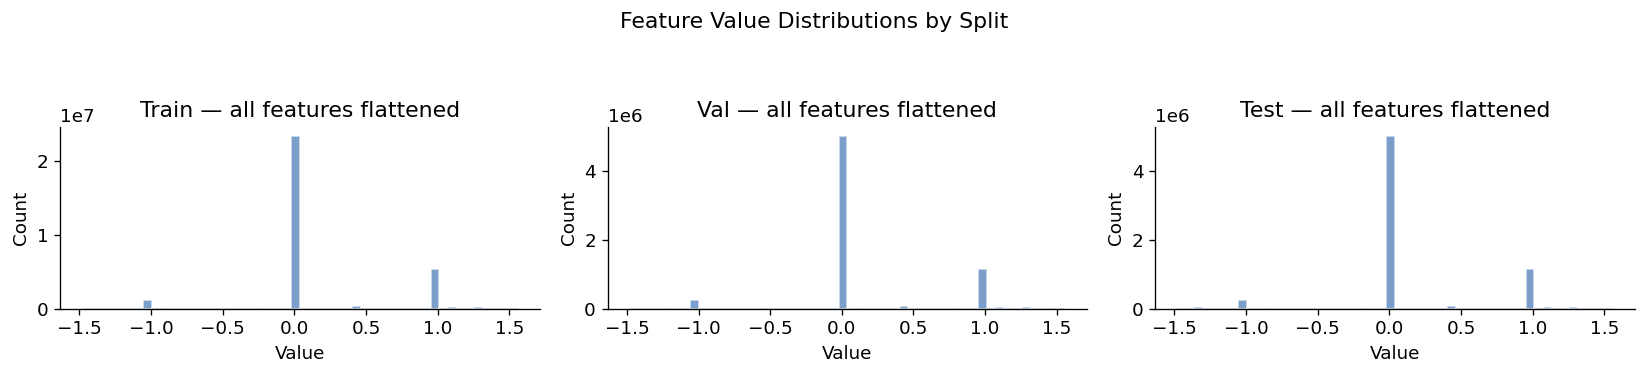

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, (name, X) in zip(axes, [("Train", X_train),
                                  ("Val", X_val),
                                  ("Test", X_test)]):
    ax.hist(X.values.flatten(), bins=50, color="#4575b4",
            edgecolor="white", alpha=0.7)
    ax.set_title(f"{name} — all features flattened")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
plt.suptitle("Feature Value Distributions by Split", y=1.03)
plt.tight_layout()
plt.show()


 ---

 ## 2. Baseline — Logistic Regression



 **Why start here:**

 - Fast to train, interpretable coefficients

 - Naturally outputs probabilities (sigmoid)

 - Sets a floor for more complex models to beat

 - Good probability calibration out of the box

In [114]:
lr_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_SEED,
    class_weight="balanced",    # handles potential class imbalance
)
lr_model.fit(X_train, y_train)

lr_pred  = lr_model.predict(X_test)
lr_prob  = lr_model.predict_proba(X_test)[:, 1]  # P(heat_wave)

print("── Logistic Regression — Test Set ──")
print(classification_report(y_test, lr_pred, target_names=le.classes_))


── Logistic Regression — Test Set ──
              precision    recall  f1-score   support

       event       0.85      0.49      0.62    181887
    no_event       0.36      0.77      0.49     68535

    accuracy                           0.57    250422
   macro avg       0.61      0.63      0.56    250422
weighted avg       0.72      0.57      0.59    250422



 ### 2.1 Logistic Regression coefficients

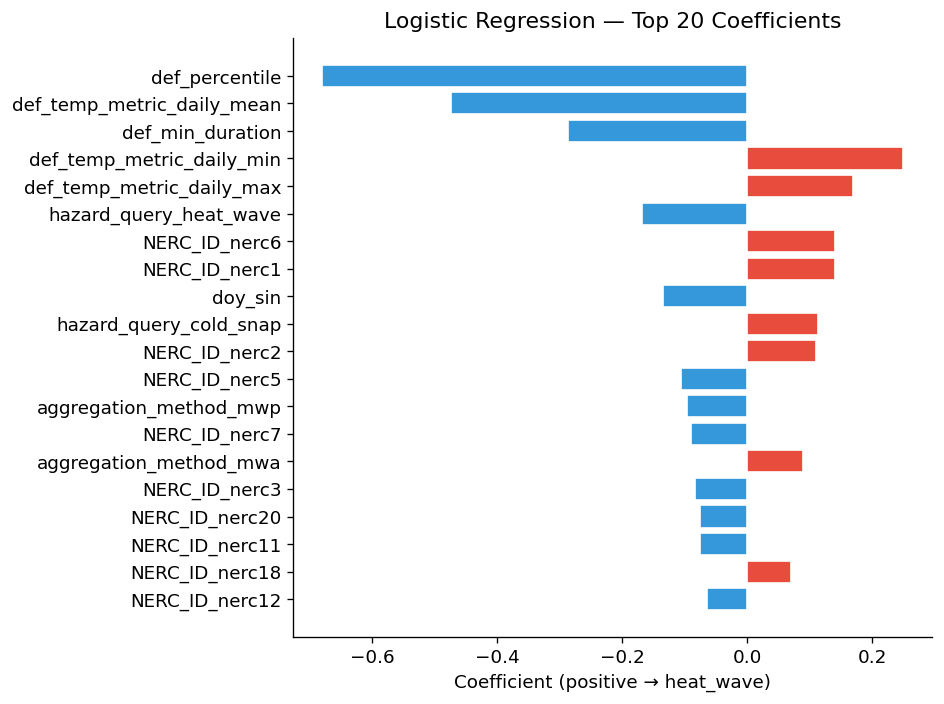

In [115]:
lr_coef = pd.DataFrame({
    "feature":     feature_names,
    "coefficient": lr_model.coef_[0],
    "abs_coef":    np.abs(lr_model.coef_[0]),
}).sort_values("abs_coef", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top_n = min(20, len(lr_coef))
top = lr_coef.head(top_n)
colors = ["#e74c3c" if c > 0 else "#3498db" for c in top["coefficient"]]
ax.barh(top["feature"], top["coefficient"], color=colors, edgecolor="white")
ax.set_xlabel("Coefficient (positive → heat_wave)")
ax.set_title("Logistic Regression — Top 20 Coefficients")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_09_lr_coefficients.png")
plt.show()


 ---

 ## 3. Random Forest



 **Why include:**

 - Handles non-linear feature interactions

 - Robust to outliers

 - Built-in feature importance (Gini / permutation)

 - Good comparison point between linear and boosted models

In [116]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("── Random Forest — Test Set ──")
print(classification_report(y_test, rf_pred, target_names=le.classes_))


── Random Forest — Test Set ──
              precision    recall  f1-score   support

       event       0.93      0.82      0.88    181887
    no_event       0.64      0.84      0.73     68535

    accuracy                           0.83    250422
   macro avg       0.79      0.83      0.80    250422
weighted avg       0.85      0.83      0.84    250422



 ---

 ## 4. Gradient Boosting (Primary Model)



 **Why this is the primary model:**

 - State-of-the-art for tabular data

 - Learns complex region × season × temperature interactions

 - Sequential boosting corrects errors from prior trees

 - Strong out-of-box performance with modest tuning

In [117]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=RANDOM_SEED,
)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("── Gradient Boosting — Test Set ──")
print(classification_report(y_test, gb_pred, target_names=le.classes_))


── Gradient Boosting — Test Set ──
              precision    recall  f1-score   support

       event       0.88      0.91      0.89    181887
    no_event       0.74      0.67      0.70     68535

    accuracy                           0.84    250422
   macro avg       0.81      0.79      0.80    250422
weighted avg       0.84      0.84      0.84    250422



 ### 4.1 Training curve — staged predictions



 Shows how performance improves with each boosting iteration.

 Useful for detecting overfitting (val loss diverges from train loss).

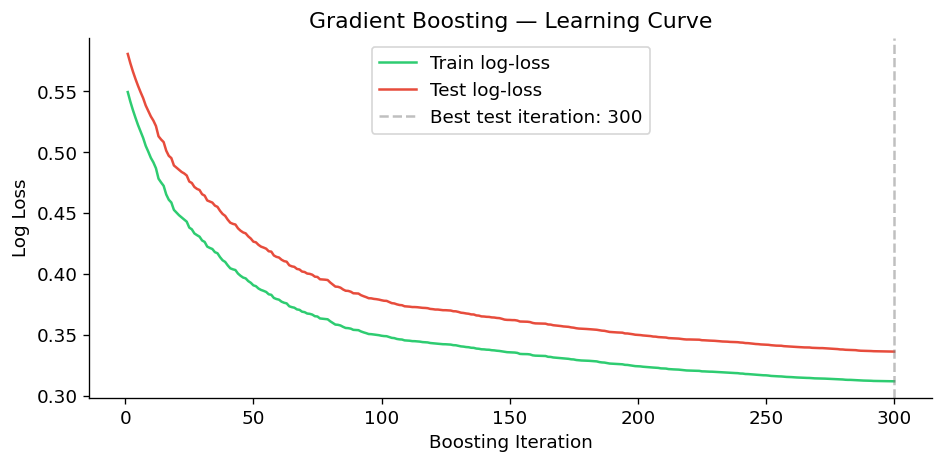

Best test log-loss at iteration 300: 0.3361


In [118]:
fig, ax = plt.subplots(figsize=(8, 4))

# Staged predictions on train and test
train_scores = []
test_scores  = []

for i, (y_train_staged, y_test_staged) in enumerate(
    zip(gb_model.staged_predict_proba(X_train),
        gb_model.staged_predict_proba(X_test))
):
    train_scores.append(log_loss(y_train, y_train_staged))
    test_scores.append(log_loss(y_test, y_test_staged))

iterations = range(1, len(train_scores) + 1)
ax.plot(iterations, train_scores, label="Train log-loss", color="#2ecc71")
ax.plot(iterations, test_scores,  label="Test log-loss",  color="#e74c3c")
ax.set_xlabel("Boosting Iteration")
ax.set_ylabel("Log Loss")
ax.set_title("Gradient Boosting — Learning Curve")
ax.legend()

# Mark best test iteration
best_iter = np.argmin(test_scores) + 1
ax.axvline(best_iter, linestyle="--", color="gray", alpha=0.5,
           label=f"Best test iteration: {best_iter}")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "ml_10_gb_learning_curve.png")
plt.show()

print(f"Best test log-loss at iteration {best_iter}: "
      f"{test_scores[best_iter - 1]:.4f}")


 ---

 ## 5. Probability Calibration



 ### Why calibrate?



 The objective requires **reliable probability estimates**, not just

 correct classifications. A model that says "P(heat_wave) = 0.7"

 should be correct ~70% of the time.



 **Method:**

 - Each base model is **already trained** on `X_train`.

 - Calibration is fit on `X_val` (held-out from training).

 - Evaluation is on `X_test` (held-out from both).

 - This is a 3-way leakage-safe setup.



 Using `cv="prefit"` tells scikit-learn the base model is already

 fitted — it only needs to learn the calibration mapping.

 ### 5.1 Calibrate all three models

In [119]:
models_uncalibrated = {
    "Logistic Regression": (lr_model, lr_prob),
    "Random Forest":       (rf_model, rf_prob),
    "Gradient Boosting":   (gb_model, gb_prob),
}

models_calibrated = {}

for name, (base_model, _) in models_uncalibrated.items():

    # ── Version-compatible calibration ────────────────────
    if SKLEARN_VERSION >= (1, 6):
        # FrozenEstimator prevents refitting the base model;
        # cv folds are used ONLY for learning the calibration mapping
        cal = CalibratedClassifierCV(
            estimator=FrozenEstimator(base_model),
            method=CALIBRATION_METHOD,
            cv=CALIBRATION_CV,
        )
    else:
        # cv="prefit": base model already fitted, calibrate on val set
        cal = CalibratedClassifierCV(
            estimator=base_model,
            method=CALIBRATION_METHOD,
            cv="prefit",
        )

    cal.fit(X_val, y_val)

    cal_pred = cal.predict(X_test)
    cal_prob = cal.predict_proba(X_test)[:, 1]

    models_calibrated[name] = {
        "model":        cal,
        "base_model":   base_model,
        "y_pred":       cal_pred,
        "y_prob":       cal_prob,
    }

    print(f"  ✅ {name} — calibrated "
          f"(method={CALIBRATION_METHOD}, cv={CALIBRATION_CV})")

  ✅ Logistic Regression — calibrated (method=isotonic, cv=5)
  ✅ Random Forest — calibrated (method=isotonic, cv=5)
  ✅ Gradient Boosting — calibrated (method=isotonic, cv=5)


 ### 5.2 Calibration curves — before vs after

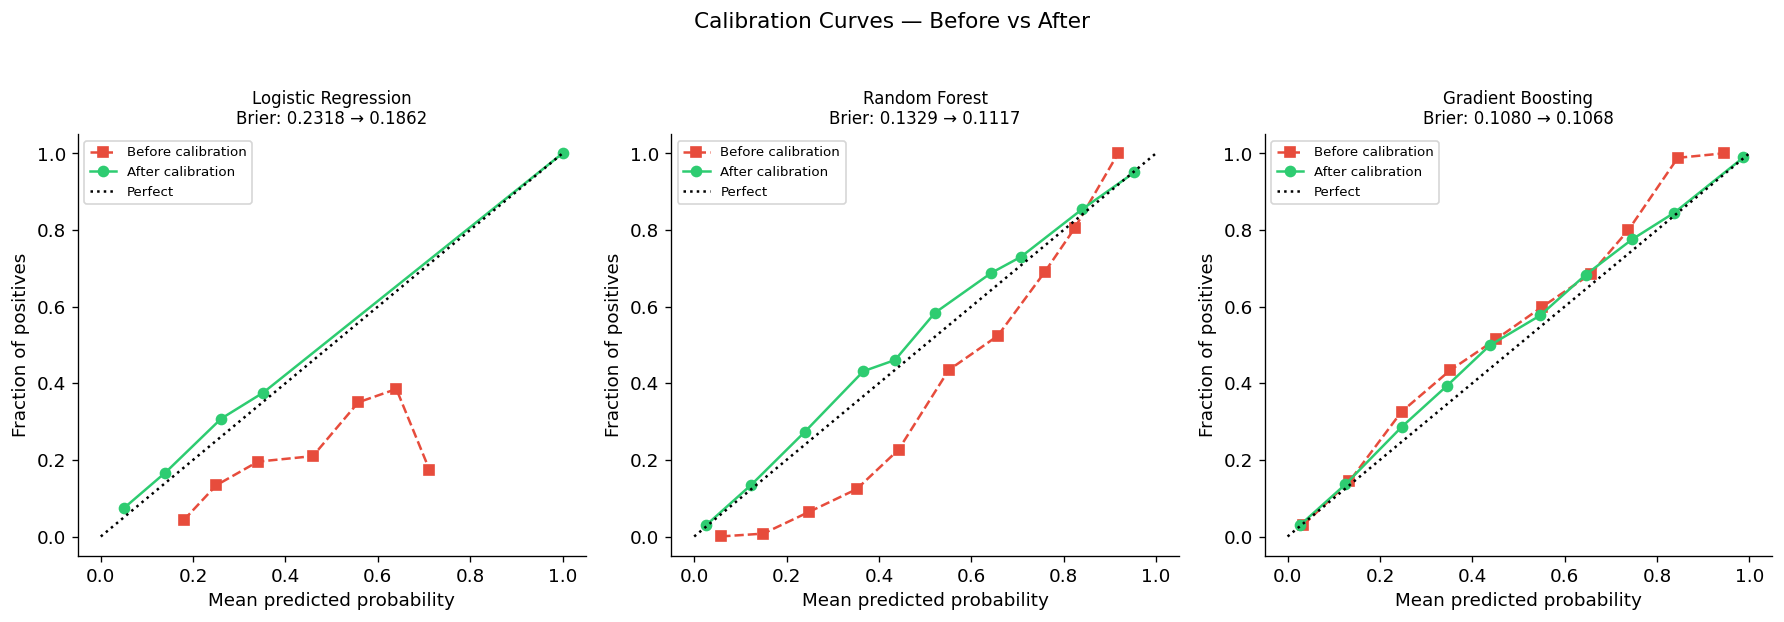

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, (base_model, uncal_prob)) in zip(
    axes, models_uncalibrated.items()
):
    cal_prob = models_calibrated[name]["y_prob"]

    # Before calibration
    frac_before, mean_before = calibration_curve(
        y_test, uncal_prob, n_bins=10, strategy="uniform"
    )
    # After calibration
    frac_after, mean_after = calibration_curve(
        y_test, cal_prob, n_bins=10, strategy="uniform"
    )

    ax.plot(mean_before, frac_before, "s--", color="#e74c3c",
            label="Before calibration", markersize=6)
    ax.plot(mean_after, frac_after, "o-", color="#2ecc71",
            label="After calibration", markersize=6)
    ax.plot([0, 1], [0, 1], "k:", label="Perfect")

    brier_before = brier_score_loss(y_test, uncal_prob)
    brier_after  = brier_score_loss(y_test, cal_prob)
    ax.set_title(f"{name}\nBrier: {brier_before:.4f} → {brier_after:.4f}",
                 fontsize=10)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)

plt.suptitle("Calibration Curves — Before vs After", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_11_calibration_curves.png")
plt.show()


 ---

 ## 6. Model Comparison



 All metrics are computed on the **test set** using **calibrated**

 probabilities.

 ### 6.1 Metrics table

In [121]:
comparison_rows = []

for name, info in models_calibrated.items():
    y_pred = info["y_pred"]
    y_prob = info["y_prob"]

    comparison_rows.append({
        "Model":             name,
        "Accuracy":          accuracy_score(y_test, y_pred),
        "F1 (macro)":        f1_score(y_test, y_pred, average="macro"),
        "ROC-AUC":           roc_auc_score(y_test, y_prob),
        "Avg Precision":     average_precision_score(y_test, y_prob),
        "Brier Score":       brier_score_loss(y_test, y_prob),
        "Log Loss":          log_loss(y_test, y_prob),
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
      .set_index("Model")
      .sort_values("Brier Score")        # lower is better
)

# Highlight best per column
print("── Model Comparison (calibrated, test set) ──\n")
display(comparison_df.style.format("{:.4f}").highlight_min(
    subset=["Brier Score", "Log Loss"],
    props="background-color: #d4edda;"
).highlight_max(
    subset=["Accuracy", "F1 (macro)", "ROC-AUC", "Avg Precision"],
    props="background-color: #d4edda;"
))


── Model Comparison (calibrated, test set) ──



,Accuracy,F1 (macro),ROC-AUC,Avg Precision,Brier Score,Log Loss
Model,,,,,,
Gradient Boosting,0.8440,0.8001,0.9094,0.7794,0.1068,0.3284
Random Forest,0.8389,0.7972,0.9017,0.7374,0.1117,0.3427
Logistic Regression,0.7267,0.4221,0.6560,0.3648,0.1862,0.5525


 ### 6.2 Select best model



 Selection criteria: **lowest Brier Score** — because the objective

 is probability accuracy for the travel-query use case, not just

 classification accuracy.

In [122]:
best_model_name = comparison_df["Brier Score"].idxmin()
best_info       = models_calibrated[best_model_name]
best_model      = best_info["model"]
best_prob       = best_info["y_prob"]
best_pred       = best_info["y_pred"]

print(f"🏆 Best model: {best_model_name}")
print(f"   Brier Score : {comparison_df.loc[best_model_name, 'Brier Score']:.4f}")
print(f"   ROC-AUC     : {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f}")


🏆 Best model: Gradient Boosting
   Brier Score : 0.1068
   ROC-AUC     : 0.9094


 ### 6.3 ROC curves — all models

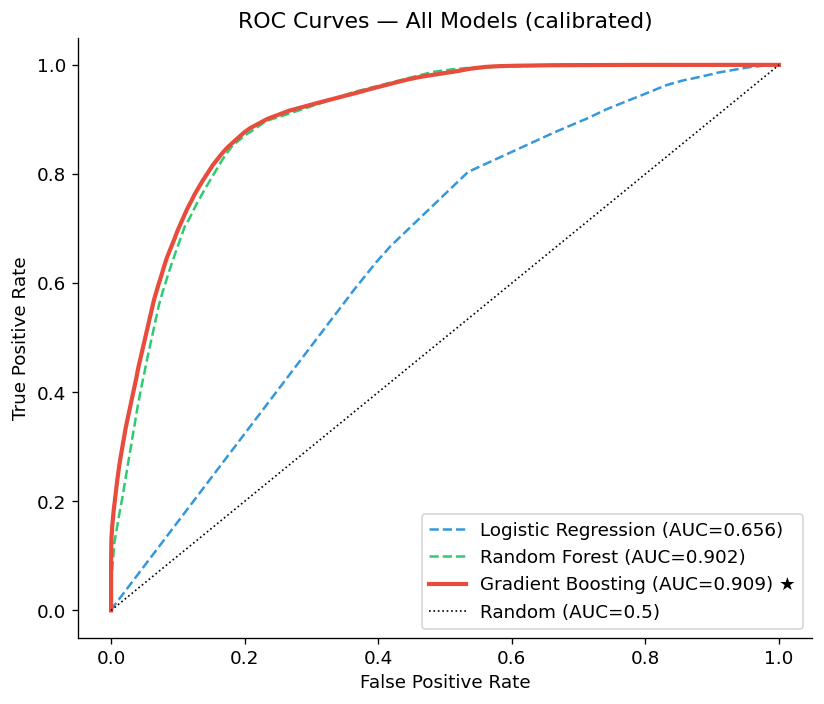

In [123]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#3498db", "#2ecc71", "#e74c3c"]

for (name, info), color in zip(models_calibrated.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, info["y_prob"])
    auc_val = roc_auc_score(y_test, info["y_prob"])
    lw = 2.5 if name == best_model_name else 1.5
    ls = "-" if name == best_model_name else "--"
    label = f"{name} (AUC={auc_val:.3f})"
    if name == best_model_name:
        label += " ★"
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=label)

ax.plot([0, 1], [0, 1], "k:", lw=1, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models (calibrated)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_12_roc_curves.png")
plt.show()


 ### 6.4 Precision-Recall curves

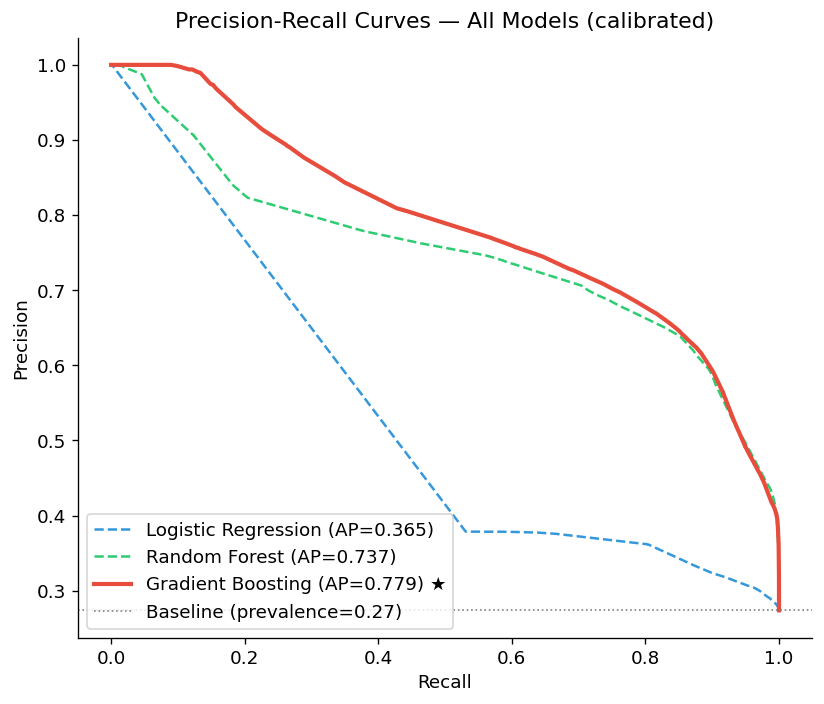

In [124]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, info), color in zip(models_calibrated.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, info["y_prob"])
    ap = average_precision_score(y_test, info["y_prob"])
    lw = 2.5 if name == best_model_name else 1.5
    ls = "-" if name == best_model_name else "--"
    label = f"{name} (AP={ap:.3f})"
    if name == best_model_name:
        label += " ★"
    ax.plot(recall, precision, color=color, lw=lw, ls=ls, label=label)

# Baseline: prevalence of positive class
prevalence = y_test.mean()
ax.axhline(prevalence, color="gray", linestyle=":", lw=1,
           label=f"Baseline (prevalence={prevalence:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models (calibrated)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_13_pr_curves.png")
plt.show()


 ---

 ## 7. Feature Importance — Best Model



 Two perspectives:

 1. **Gini / impurity-based** importance (from the tree model)

 2. **Coefficient-based** (from Logistic Regression for comparison)

In [125]:
# Extract base model from the calibrated wrapper
base_best = best_info["base_model"]

if hasattr(base_best, "feature_importances_"):
    importances = base_best.feature_importances_
elif hasattr(base_best, "coef_"):
    importances = np.abs(base_best.coef_[0])
else:
    importances = np.zeros(len(feature_names))

feat_imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values("importance", ascending=False)
)


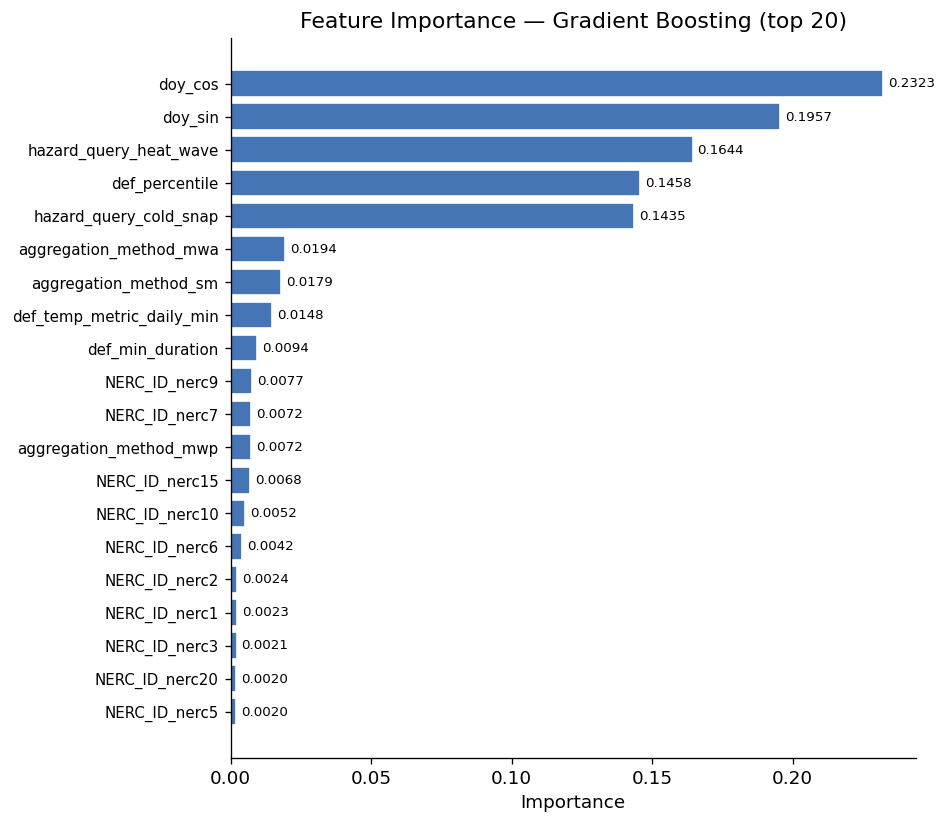

In [126]:
fig, ax = plt.subplots(figsize=(8, 7))
top_n = min(20, len(feat_imp))
top   = feat_imp.head(top_n)

bars = ax.barh(
    range(top_n), top["importance"].values,
    color="#4575b4", edgecolor="white"
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top["feature"].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title(f"Feature Importance — {best_model_name} (top {top_n})")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_14_feature_importance.png")
plt.show()


In [ ]:
print("── Full Feature Importance Ranking ──\n")
display(feat_imp.reset_index(drop=True))


 ---

 ## 8. Error Analysis



 Examine where the best model gets it wrong to understand failure modes and potential data/feature improvements.

 ### 8.1 Confusion matrix

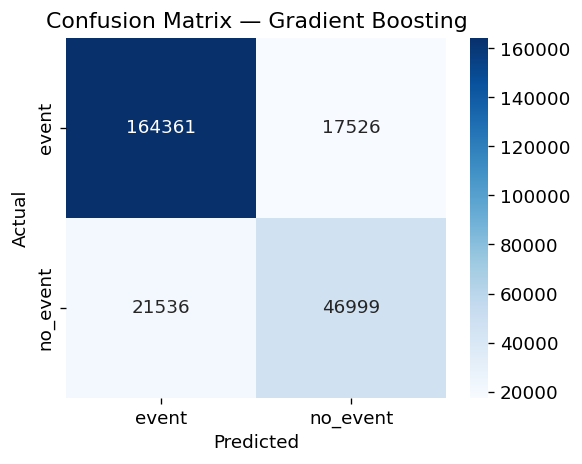

In [127]:
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_15_confusion_matrix.png")
plt.show()


 ### 8.2 Probability distribution by true class

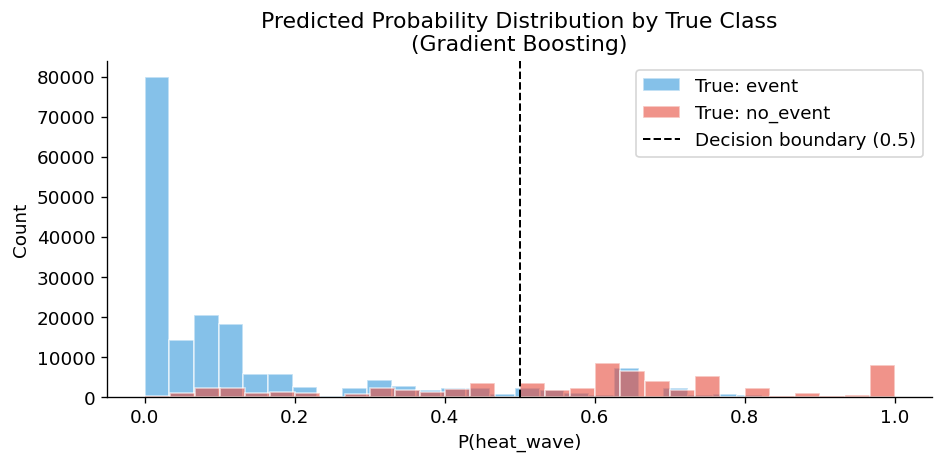

In [128]:
fig, ax = plt.subplots(figsize=(8, 4))

for cls_idx, cls_name, color in [(0, le.classes_[0], "#3498db"),
                                   (1, le.classes_[1], "#e74c3c")]:
    mask = y_test == cls_idx
    ax.hist(best_prob[mask], bins=30, alpha=0.6, label=f"True: {cls_name}",
            color=color, edgecolor="white")

ax.axvline(0.5, color="black", linestyle="--", lw=1.2,
           label="Decision boundary (0.5)")
ax.set_xlabel("P(heat_wave)")
ax.set_ylabel("Count")
ax.set_title(f"Predicted Probability Distribution by True Class\n"
             f"({best_model_name})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_16_prob_distribution.png")
plt.show()


 ### 8.3 Misclassified samples analysis

In [129]:
# Reload test split for readable columns
test_readable = pd.read_csv(CLEANED_DIR / "test.csv")
test_readable["y_true"]    = y_test
test_readable["y_pred"]    = best_pred
test_readable["p_heatwave"] = best_prob
test_readable["correct"]   = (y_test == best_pred)

misclassified = test_readable[~test_readable["correct"]]
print(f"Misclassified: {len(misclassified)} / {len(test_readable)} "
      f"({len(misclassified)/len(test_readable):.1%})")


Misclassified: 39062 / 250422 (15.6%)


In [130]:
# Show misclassified rows sorted by confidence (most confident errors first)
misc_sorted = misclassified.sort_values(
    "p_heatwave",
    ascending=False,
    key=lambda s: np.abs(s - 0.5)   # distance from boundary
)

display_cols = [
    "hazard_type", "NERC_ID", "extreme_temperature_C",
    "centroid_date", "duration_days", "spatial_coverage_pct",
    "p_heatwave", "y_pred", "y_true",
]
display_cols = [c for c in display_cols if c in misc_sorted.columns]

print("\n── Most confident misclassifications (top 15) ──")
display(misc_sorted[display_cols].head(15))



── Most confident misclassifications (top 15) ──


,NERC_ID,extreme_temperature_C,duration_days,spatial_coverage_pct,p_heatwave,y_pred,y_true
54900,nerc7,-19.2709,4.0000,88.3721,0.0000,0,1
91796,nerc7,-17.2179,2.0000,73.2558,0.0000,0,1
91929,nerc7,-17.2179,2.0000,73.2558,0.0000,0,1
148045,nerc3,37.6495,2.0000,55.3191,0.0002,0,1
148118,nerc3,37.6495,2.0000,55.3191,0.0002,0,1
16249,nerc4,32.0916,4.0000,35.0877,0.0002,0,1
55016,nerc7,-19.2709,4.0000,88.3721,0.0002,0,1
55116,nerc7,-19.2709,4.0000,88.3721,0.0002,0,1
91939,nerc3,1.2541,2.0000,55.3191,0.0002,0,1
54905,nerc7,-19.2709,3.0000,81.3953,0.0002,0,1


 ### 8.4 Error patterns by NERC region

── Accuracy by NERC Region ──


,n_events,n_correct,accuracy,mean_p_heatwave
NERC_ID,,,,
nerc3,16612,13436,0.8088,0.2683
nerc4,16239,13329,0.8208,0.2626
nerc2,16243,13543,0.8338,0.2845
nerc1,16812,14040,0.8351,0.2933
nerc9,15593,13089,0.8394,0.2625
nerc8,15473,13039,0.8427,0.2524
nerc11,14839,12507,0.8428,0.2298
nerc7,16104,13609,0.8451,0.2637
nerc18,15357,12981,0.8453,0.2559


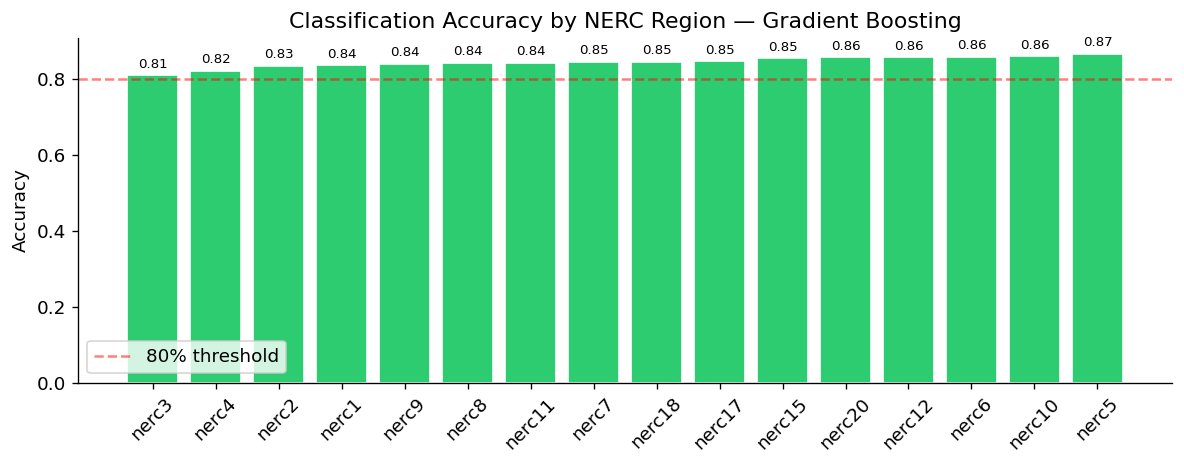

In [131]:
if "NERC_ID" in test_readable.columns:
    region_acc = (
        test_readable
        .groupby("NERC_ID")
        .agg(
            n_events=("correct", "size"),
            n_correct=("correct", "sum"),
            accuracy=("correct", "mean"),
            mean_p_heatwave=("p_heatwave", "mean"),
        )
        .sort_values("accuracy")
    )

    print("── Accuracy by NERC Region ──")
    display(region_acc)

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(
        region_acc.index, region_acc["accuracy"],
        color=["#e74c3c" if a < 0.8 else "#2ecc71"
               for a in region_acc["accuracy"]],
        edgecolor="white",
    )
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.axhline(0.8, color="red", linestyle="--", alpha=0.5,
               label="80% threshold")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Classification Accuracy by NERC Region — {best_model_name}")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ml_17_accuracy_by_region.png")
    plt.show()


 ---

 ## 9. Regional Probability Query Demo



 This demonstrates the end-user query:

 > *"On date X, which NERC region has the lowest heat-wave probability?"*

 > *"If I travel to region Y on date X, what's the risk?"*



 ### How it works:

 1. User provides a query date.

 2. For each NERC region, we construct a feature vector with:

    - Cyclical day-of-year from the query date

    - Median numeric features from that region's history

    - Most recent trailing rate and days-since-last-event

 3. Pass through the trained (calibrated) model → P(heat_wave)

 4. Rank regions and provide risk labels.

In [132]:
# Load full ML-ready dataset for feature reference
ml_ready = pd.read_csv(CLEANED_DIR / "ml_ready.csv")
ml_ready["centroid_date"] = pd.to_datetime(ml_ready["centroid_date"])

# Default definition for travel queries — Def2 is a moderate
# middle-ground (daily mean, 95th/5th percentile, 2+ days) [1]
DEFAULT_QUERY_DEFINITION = "Def2"

# Definition metadata (same as ml_preparation.ipynb)
DEFINITION_META = {
    "Def1":  {"def_temp_metric": "daily_mean", "def_percentile": 90.0,  "def_min_duration": 2.0},
    "Def2":  {"def_temp_metric": "daily_mean", "def_percentile": 95.0,  "def_min_duration": 2.0},
    "Def3":  {"def_temp_metric": "daily_mean", "def_percentile": 98.0,  "def_min_duration": 2.0},
    "Def4":  {"def_temp_metric": "daily_mean", "def_percentile": 99.0,  "def_min_duration": 2.0},
    "Def5":  {"def_temp_metric": "daily_max",  "def_percentile": 95.0,  "def_min_duration": 2.0},
    "Def6":  {"def_temp_metric": "daily_max",  "def_percentile": 97.5,  "def_min_duration": 3.0},
    "Def7":  {"def_temp_metric": "daily_max",  "def_percentile": 90.0,  "def_min_duration": 3.0},
    "Def8":  {"def_temp_metric": "daily_max",  "def_percentile": 90.0,  "def_min_duration": 3.0},
    "Def9":  {"def_temp_metric": "daily_min",  "def_percentile": 95.0,  "def_min_duration": 2.0},
    "Def10": {"def_temp_metric": "daily_min",  "def_percentile": 97.5,  "def_min_duration": 3.0},
    "Def11": {"def_temp_metric": "daily_min",  "def_percentile": 90.0,  "def_min_duration": 3.0},
    "Def12": {"def_temp_metric": "daily_min",  "def_percentile": 90.0,  "def_min_duration": 3.0},
}

print(f"Default query definition: {DEFAULT_QUERY_DEFINITION}")
print(f"  → {DEFINITION_META[DEFAULT_QUERY_DEFINITION]}")



Default query definition: Def2
  → {'def_temp_metric': 'daily_mean', 'def_percentile': 95.0, 'def_min_duration': 2.0}


In [133]:

def query_regional_probabilities(
    query_date_str: str,
    model,
    label_encoder,
    feature_names_list: list[str],
    encoding_metadata: dict,
    reference_df: pd.DataFrame,
    definition: str = None,
    hazard_query: str = "heat_wave",
) -> pd.DataFrame:
    """
    Produce P(event) for each NERC region on a given date.
    No temperature needed — the model predicts based on
    region, season, definition, and hazard type.
    """
    if definition is None:
        definition = DEFAULT_QUERY_DEFINITION

    def_meta = DEFINITION_META.get(definition)
    if def_meta is None:
        raise ValueError(f"Unknown definition '{definition}'.")

    q_date  = pd.Timestamp(query_date_str)
    doy     = q_date.dayofyear
    doy_sin = np.sin(2 * np.pi * doy / 365.0)
    doy_cos = np.cos(2 * np.pi * doy / 365.0)

    nerc_regions = sorted(reference_df["NERC_ID"].unique())
    rows = []

    for region in nerc_regions:
        region_df = reference_df[reference_df["NERC_ID"] == region]
        agg_method = (region_df["aggregation_method"].mode()[0]
                      if len(region_df) else "unknown")

        rows.append({
            "def_percentile":     def_meta["def_percentile"],
            "def_min_duration":   def_meta["def_min_duration"],
            "doy_sin":            doy_sin,
            "doy_cos":            doy_cos,
            "NERC_ID":            region,
            "aggregation_method": agg_method,
            "def_temp_metric":    def_meta["def_temp_metric"],
            "hazard_query":       hazard_query,
        })

    query_df = pd.DataFrame(rows)
    nerc_ids = query_df["NERC_ID"].values

    # One-hot encode all categorical columns
    cat_cols = [c for c in ["aggregation_method", "def_temp_metric",
                            "hazard_query"] if c in query_df.columns]
    query_encoded = pd.get_dummies(
        query_df.drop(columns=["NERC_ID"]),
        columns=cat_cols,
    )
    nerc_dummies = pd.get_dummies(query_df[["NERC_ID"]], columns=["NERC_ID"])
    query_encoded = pd.concat([query_encoded, nerc_dummies], axis=1)

    # Align to training features
    query_encoded = query_encoded.reindex(
        columns=feature_names_list, fill_value=0
    )

    # Scale numeric features
    num_cols = encoding_metadata.get("num_feature_cols", [])
    if num_cols:
        query_encoded[num_cols] = scaler.transform(query_encoded[num_cols])

    # Predict P(event)
    probs = model.predict_proba(query_encoded.values)[:, 1]

    result = pd.DataFrame({
        "NERC_ID":       nerc_ids,
        f"P({hazard_query})": probs,
        "Risk Level":    np.where(
            probs < LOW_RISK_THRESHOLD,  "✅ Low",
            np.where(probs < HIGH_RISK_THRESHOLD, "🟡 Moderate", "🔴 High")
        ),
    }).sort_values(f"P({hazard_query})", ascending=True).reset_index(drop=True)

    return result

### 9.1 Summer query — expect higher heat wave probabilities

Using **Def 2** (daily mean, 95th percentile, 2+ days) as the
moderate baseline definition [1].

In [170]:
summer_date = "2024-07-05"
print(f"═══ Heat Wave Query: {summer_date} ═══\n")
summer_result = query_regional_probabilities(
    query_date_str=summer_date,
    model=best_model,
    label_encoder=le,
    reference_df=ml_ready,
    feature_names_list=feature_names,
    encoding_metadata=encoding_meta,
    definition=DEFAULT_QUERY_DEFINITION,
    hazard_query="heat_wave",
)
display(summer_result)


═══ Heat Wave Query: 2024-07-05 ═══



,NERC_ID,P(heat_wave),Risk Level
0,nerc6,0.5180,🟡 Moderate
1,nerc3,0.5180,🟡 Moderate
2,nerc10,0.5490,🟡 Moderate
3,nerc12,0.5490,🟡 Moderate
4,nerc4,0.5490,🟡 Moderate
5,nerc8,0.5490,🟡 Moderate
6,nerc18,0.5978,🟡 Moderate
7,nerc1,0.6277,🔴 High
8,nerc9,0.6277,🔴 High
9,nerc17,0.6277,🔴 High


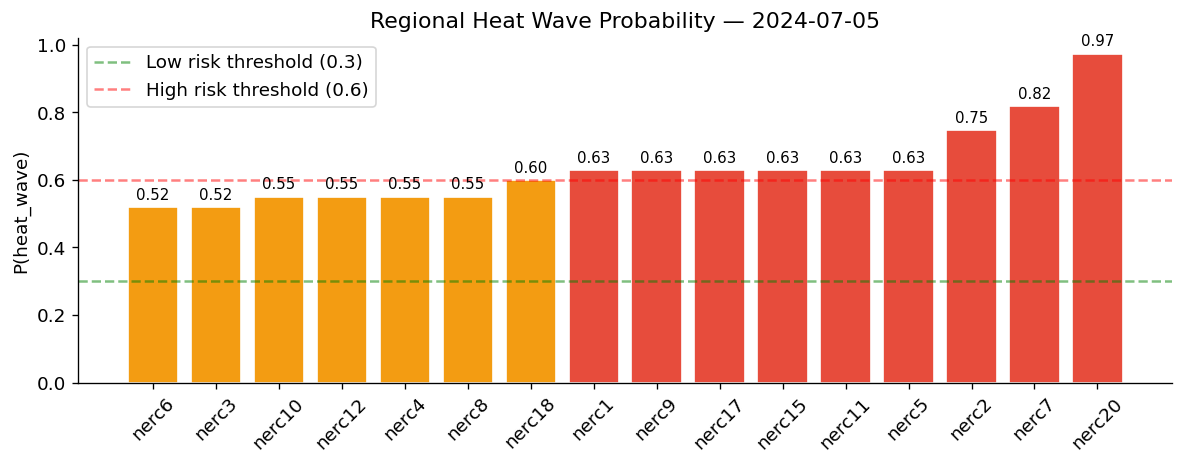

In [171]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    summer_result["NERC_ID"],
    summer_result["P(heat_wave)"],
    color=["#2ecc71" if p < LOW_RISK_THRESHOLD
           else "#f39c12" if p < HIGH_RISK_THRESHOLD
           else "#e74c3c"
           for p in summer_result["P(heat_wave)"]],
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.axhline(LOW_RISK_THRESHOLD, color="green", linestyle="--", alpha=0.5,
           label=f"Low risk threshold ({LOW_RISK_THRESHOLD})")
ax.axhline(HIGH_RISK_THRESHOLD, color="red", linestyle="--", alpha=0.5,
           label=f"High risk threshold ({HIGH_RISK_THRESHOLD})")
ax.set_ylabel("P(heat_wave)")
ax.set_title(f"Regional Heat Wave Probability — {summer_date}")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_18_query_summer.png")
plt.show()


 ### 9.2 Winter query — expect higher cold snap probabilities

In [172]:
winter_date = "2024-01-25"
print(f"═══ Cold Snap Query: {winter_date} ═══\n")
winter_result = query_regional_probabilities(
    query_date_str=winter_date,
    model=best_model,
    label_encoder=le,
    reference_df=ml_ready,
    feature_names_list=feature_names,
    encoding_metadata=encoding_meta,
    definition=DEFAULT_QUERY_DEFINITION,
    hazard_query="cold_snap",
)
display(winter_result)


═══ Cold Snap Query: 2024-01-25 ═══



,NERC_ID,P(cold_snap),Risk Level
0,nerc2,0.5490,🟡 Moderate
1,nerc4,0.5781,🟡 Moderate
2,nerc20,0.5818,🟡 Moderate
3,nerc10,0.5818,🟡 Moderate
4,nerc6,0.5818,🟡 Moderate
5,nerc7,0.5818,🟡 Moderate
6,nerc12,0.5935,🟡 Moderate
7,nerc8,0.5935,🟡 Moderate
8,nerc18,0.6277,🔴 High
9,nerc17,0.6277,🔴 High


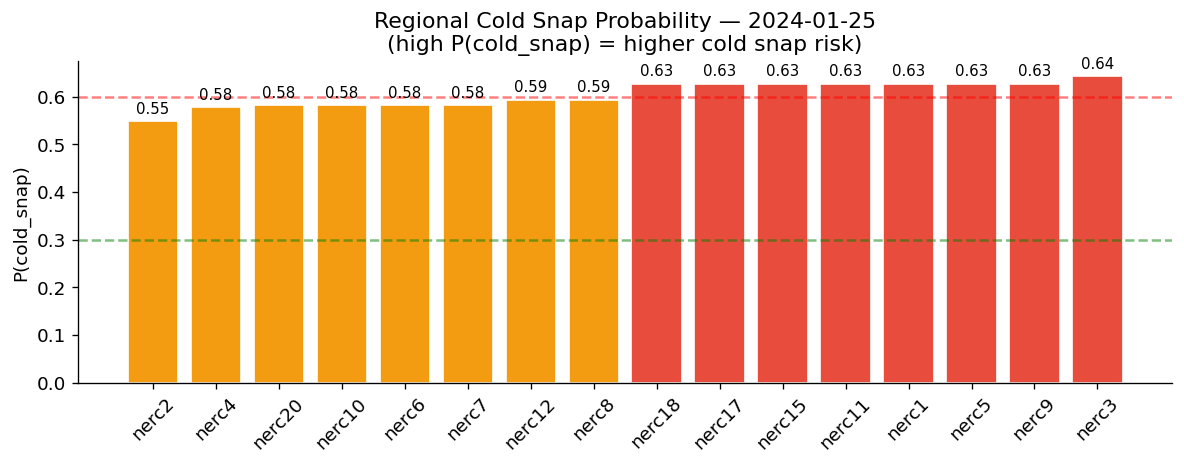

In [173]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    winter_result["NERC_ID"],
    winter_result["P(cold_snap)"],
    color=["#2ecc71" if p < LOW_RISK_THRESHOLD
           else "#f39c12" if p < HIGH_RISK_THRESHOLD
           else "#e74c3c"
           for p in winter_result["P(cold_snap)"]],
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.axhline(LOW_RISK_THRESHOLD, color="green", linestyle="--", alpha=0.5)
ax.axhline(HIGH_RISK_THRESHOLD, color="red", linestyle="--", alpha=0.5)
ax.set_ylabel("P(cold_snap)")
ax.set_title(f"Regional Cold Snap Probability — {winter_date}\n"
             f"(high P(cold_snap) = higher cold snap risk)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_19_query_winter.png")
plt.show()


 ### 9.3 Side-by-side summer vs winter comparison

── Seasonal Comparison ──



,NERC_ID,Summer P(hw),Winter P(cs),Seasonal Swing
15,nerc20,0.9720,0.5818,0.3901
14,nerc7,0.8172,0.5818,0.2354
13,nerc2,0.7460,0.5490,0.1970
7,nerc1,0.6277,0.6277,0.0000
8,nerc9,0.6277,0.6277,0.0000
9,nerc17,0.6277,0.6277,0.0000
10,nerc15,0.6277,0.6277,0.0000
11,nerc11,0.6277,0.6277,0.0000
12,nerc5,0.6277,0.6277,0.0000
4,nerc4,0.5490,0.5781,-0.0291


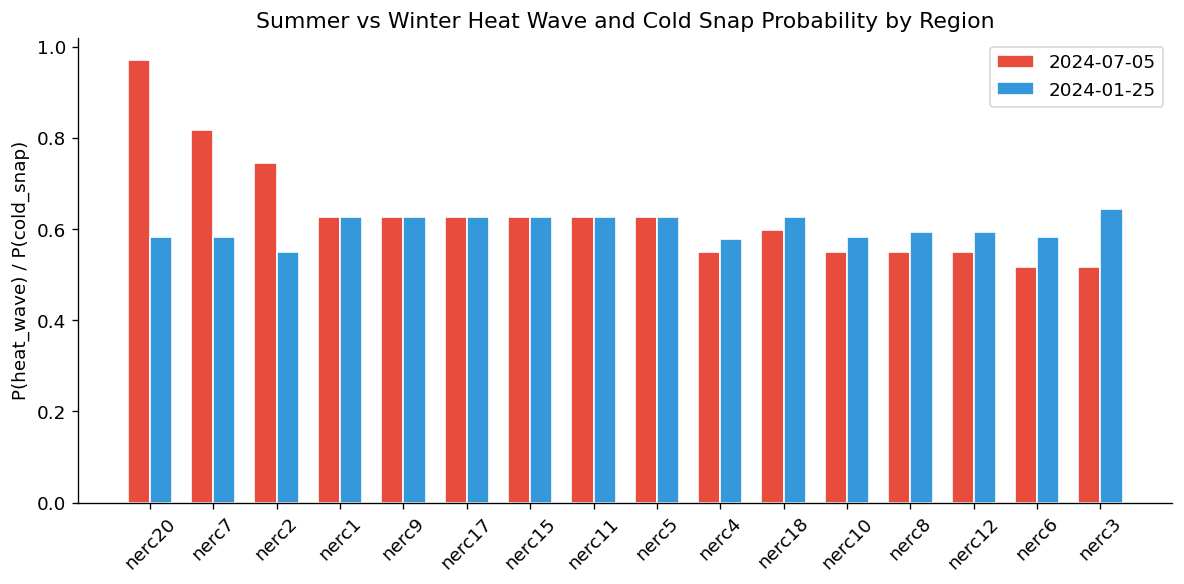

In [174]:
compare = (
    summer_result[["NERC_ID", "P(heat_wave)"]]
    .rename(columns={"P(heat_wave)": "Summer P(hw)"})
    .merge(
        winter_result[["NERC_ID", "P(cold_snap)"]]
        .rename(columns={"P(cold_snap)": "Winter P(cs)"}),
        on="NERC_ID",
    )
)
compare["Seasonal Swing"] = compare["Summer P(hw)"] - compare["Winter P(cs)"]
compare = compare.sort_values("Seasonal Swing", ascending=False)

print("── Seasonal Comparison ──\n")
display(compare)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare))
w = 0.35
ax.bar(x - w/2, compare["Summer P(hw)"], w, label=summer_date,
       color="#e74c3c", edgecolor="white")
ax.bar(x + w/2, compare["Winter P(cs)"], w, label=winter_date,
       color="#3498db", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(compare["NERC_ID"], rotation=45)
ax.set_ylabel("P(heat_wave) / P(cold_snap)")
ax.set_title("Summer vs Winter Heat Wave and Cold Snap Probability by Region")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_20_seasonal_comparison.png")
plt.show()


### 9.4 How does definition choice affect probability?

The same date and region can have different heat-wave probabilities
depending on which definition is used. Stricter definitions
(higher percentile) naturally produce lower probabilities [1].

In [175]:
# Use the panel dataframe (already in memory from ml_preparation)
# instead of reloading the old ml_ready.csv
ml_ready = pd.read_csv(CLEANED_DIR / "ml_ready.csv")

# If ml_ready was saved BEFORE the panel restructuring,
# reload the panel version instead:
if "NERC_ID" not in ml_ready.columns:
    ml_ready = pd.read_csv(CLEANED_DIR / "train.csv")  # or whichever has NERC_ID
    ml_ready["centroid_date"] = pd.to_datetime(
        ml_ready.get("centroid_date", ml_ready.get("date"))
    )

print(f"Reference data columns: {list(ml_ready.columns)}")
print(f"Shape: {ml_ready.shape}")
assert "NERC_ID" in ml_ready.columns, "NERC_ID column missing!"
ml_ready.head()

Reference data columns: ['hazard_type', 'aggregation_method', 'definition_id', 'start_date', 'end_date', 'centroid_date', 'duration_days', 'NERC_ID', 'spatial_coverage_pct', 'extreme_temperature_C', 'def_temp_metric', 'def_percentile', 'def_min_duration', 'doy_sin', 'doy_cos', 'region_hazard_rate_30d', 'days_since_last_event']
Shape: (86128, 17)


,hazard_type,aggregation_method,definition_id,start_date,end_date,centroid_date,duration_days,NERC_ID,spatial_coverage_pct,extreme_temperature_C,def_temp_metric,def_percentile,def_min_duration,doy_sin,doy_cos,region_hazard_rate_30d,days_since_last_event
0,cold_snap,mwp,Def1,1980-01-01,1980-01-02,1980-01-01,2,nerc9,69.1358,0.6034,daily_mean,90.0000,2,0.0172,0.9999,0.0000,999.0000
1,cold_snap,mwp,Def1,1980-01-01,1980-01-02,1980-01-01,2,nerc3,36.7021,0.1177,daily_mean,90.0000,2,0.0172,0.9999,0.0000,999.0000
2,cold_snap,sm,Def9,1980-01-02,1980-01-03,1980-01-02,2,nerc4,94.7368,3.3186,daily_min,95.0000,2,0.0344,0.9994,0.0000,999.0000
3,cold_snap,sm,Def1,1980-01-01,1980-01-02,1980-01-02,2,nerc10,54.1322,0.2980,daily_mean,90.0000,2,0.0344,0.9994,0.0000,999.0000
4,cold_snap,mwp,Def5,1980-01-01,1980-01-03,1980-01-02,3,nerc4,94.7368,3.8947,daily_max,95.0000,2,0.0344,0.9994,0.0000,999.0000


In [177]:

available_regions = sorted(ml_ready["NERC_ID"].unique())
print(f"Available NERC regions: {available_regions}")

query_region = ml_ready["NERC_ID"].value_counts().idxmax()
query_date   = "2024-07-05"
query_hazard = "heat_wave"
prob_col     = f"P({query_hazard})"

print(f"\nSelected query region: '{query_region}' (most events)")
print(f"Query date: {query_date}")

# %%
def_results = []

for def_id, meta in DEFINITION_META.items():
    try:
        # ── KEY FIX: use keyword arguments so order doesn't matter ──
        result = query_regional_probabilities(
            query_date_str=query_date,
            model=best_model,
            label_encoder=le,
            reference_df=ml_ready,
            feature_names_list=feature_names,
            encoding_metadata=encoding_meta,
            definition=def_id,
            hazard_query=query_hazard,
        )
        region_row = result[result["NERC_ID"] == query_region]

        if len(region_row) > 0:
            # Find the probability column dynamically
            p_col = [c for c in result.columns if c.startswith("P(")][0]
            def_results.append({
                "Definition":   def_id,
                "Temp Metric":  meta["def_temp_metric"],
                "Percentile":   meta["def_percentile"],
                "Min Duration": meta["def_min_duration"],
                prob_col:       region_row[p_col].values[0],
            })
        else:
            print(f"  ⚠️  {def_id}: region '{query_region}' not found")

    except Exception as e:
        print(f"  ⚠️  {def_id}: query failed — {e}")

# ── Display results ───────────────────────────────────────
if not def_results:
    print(f"\n❌ No results for region '{query_region}'.")
else:
    def_compare = (
        pd.DataFrame(def_results)
          .sort_values(prob_col, ascending=False)
          .reset_index(drop=True)
    )
    print(f"\n═══ {query_region} on {query_date} — {prob_col} by definition ═══\n")
    display(def_compare)

Available NERC regions: ['nerc1', 'nerc10', 'nerc11', 'nerc12', 'nerc15', 'nerc17', 'nerc18', 'nerc2', 'nerc20', 'nerc3', 'nerc4', 'nerc5', 'nerc6', 'nerc7', 'nerc8', 'nerc9']

Selected query region: 'nerc2' (most events)
Query date: 2024-07-05

═══ nerc2 on 2024-07-05 — P(heat_wave) by definition ═══



,Definition,Temp Metric,Percentile,Min Duration,P(heat_wave)
0,Def1,daily_mean,90.0000,2.0000,1.0000
1,Def9,daily_min,95.0000,2.0000,1.0000
2,Def11,daily_min,90.0000,3.0000,0.9720
3,Def12,daily_min,90.0000,3.0000,0.9720
4,Def7,daily_max,90.0000,3.0000,0.9205
5,Def8,daily_max,90.0000,3.0000,0.9205
6,Def2,daily_mean,95.0000,2.0000,0.7460
7,Def5,daily_max,95.0000,2.0000,0.7460
8,Def6,daily_max,97.5000,3.0000,0.4641
9,Def10,daily_min,97.5000,3.0000,0.4641


 ---

 ## 10. Save Final Model & Report

 ### 10.1 Save calibrated best model

In [182]:
import pickle

for name, info in models_calibrated.items():
    # Create a safe filename from model name
    safe_name = name.lower().replace(" ", "_")
    pkl_path = MODEL_DIR / f"{safe_name}.pkl"

    model_data = {
        "model":              info["model"],           # calibrated model
        "base_model":         info["base_model"],      # uncalibrated base
        "model_name":         name,
        "label_encoder":      le,
        "scaler":             scaler,
        "feature_names":      feature_names,
        "encoding_meta":      encoding_meta,
        "calibration_method": CALIBRATION_METHOD,
        "is_best_model":      (name == best_model_name),
    }

    with open(pkl_path, "wb") as f:
        pickle.dump(model_data, f)

    tag = " ★ (best)" if name == best_model_name else ""
    print(f"  ✅ {name}{tag} → {pkl_path}")

print(f"\nAll models saved to: {MODEL_DIR}/")


  ✅ Logistic Regression → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week3\ml_models\logistic_regression.pkl
  ✅ Random Forest → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week3\ml_models\random_forest.pkl
  ✅ Gradient Boosting ★ (best) → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week3\ml_models\gradient_boosting.pkl

All models saved to: C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week3\ml_models/


 ### 10.2 Save comparison table

In [179]:
comparison_df.to_csv(MODEL_DIR / "model_comparison.csv")
print(f"✅ Comparison table → {MODEL_DIR / 'model_comparison.csv'}")


✅ Comparison table → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week3\ml_models\model_comparison.csv


 ### 10.3 Save feature importance

In [180]:
feat_imp.to_csv(MODEL_DIR / "feature_importance.csv", index=False)
print(f"✅ Feature importance → {MODEL_DIR / 'feature_importance.csv'}")


✅ Feature importance → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week3\ml_models\feature_importance.csv


 ### 10.4 Final output inventory

In [181]:
print()
print("─" * 60)
print("  ML TRAINING COMPLETE")
print("─" * 60)
print()
print(f"  🏆 Best model : {best_model_name}")
print(f"     Brier Score: {model_bundle['metrics']['brier_score']:.4f}")
print(f"     ROC-AUC    : {model_bundle['metrics']['roc_auc']:.4f}")
print(f"     Calibration: {CALIBRATION_METHOD}")
print()
print("  📁 models/")
print(f"  ├── best_model.joblib        ← full model bundle")
print(f"  ├── model_comparison.csv     ← all models metrics")
print(f"  └── feature_importance.csv   ← ranked features")
print()
print("  📁 figures/")
print("  ├── ml_09_lr_coefficients.png")
print("  ├── ml_10_gb_learning_curve.png")
print("  ├── ml_11_calibration_curves.png")
print("  ├── ml_12_roc_curves.png")
print("  ├── ml_13_pr_curves.png")
print("  ├── ml_14_feature_importance.png")
print("  ├── ml_15_confusion_matrix.png")
print("  ├── ml_16_prob_distribution.png")
print("  ├── ml_17_accuracy_by_region.png")
print("  ├── ml_18_query_summer.png")
print("  ├── ml_19_query_winter.png")
print("  └── ml_20_seasonal_comparison.png")
print()
print("─" * 60)



────────────────────────────────────────────────────────────
  ML TRAINING COMPLETE
────────────────────────────────────────────────────────────

  🏆 Best model : Gradient Boosting
     Brier Score: 0.1068
     ROC-AUC    : 0.9094
     Calibration: isotonic

  📁 models/
  ├── best_model.joblib        ← full model bundle
  ├── model_comparison.csv     ← all models metrics
  └── feature_importance.csv   ← ranked features

  📁 figures/
  ├── ml_09_lr_coefficients.png
  ├── ml_10_gb_learning_curve.png
  ├── ml_11_calibration_curves.png
  ├── ml_12_roc_curves.png
  ├── ml_13_pr_curves.png
  ├── ml_14_feature_importance.png
  ├── ml_15_confusion_matrix.png
  ├── ml_16_prob_distribution.png
  ├── ml_17_accuracy_by_region.png
  ├── ml_18_query_summer.png
  ├── ml_19_query_winter.png
  └── ml_20_seasonal_comparison.png

────────────────────────────────────────────────────────────


 ### 10.5 Quick-load snippet for inference



 Copy this into any downstream notebook or script to use the model:



 ```python

 import joblib

 bundle = joblib.load("models/best_model.joblib")



 model          = bundle["model"]

 le             = bundle["label_encoder"]

 scaler         = bundle["scaler"]

 feature_names  = bundle["feature_names"]

 encoding_meta  = bundle["encoding_meta"]



 # Predict on new data

 probs = model.predict_proba(X_new)[:, 1]  # P(heat_wave)

 ```